In [23]:
import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [24]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [25]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent. Paper uses p=2.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """

    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """

    wn = f3dB / (Fs / 2)  # normalized cutoff
    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    # This function creates the coefficients of the Butterworth filter
    # b = numerator coefficient
    # a = denumerator coefficients
    b, a = signal.butter(order, wn, btype='low')

    # Apply the filter at the real and complex parts seperately
    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    # Recombine the signal
    return y_i + 1j * y_q


def pa_model(x, Fs, BO_dB=5.0, p=2.0, f3dB=37e9):
    """
    Paper-style PA model:
        x -> Rapp nonlinearity -> 3rd-order Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform.
    Fs : float
        Sample rate [Hz].
    BO_dB : float
        Back-off setting in dB. Use 7, 5, 3 for weak/moderate/strong.
    p : float
        Rapp exponent. Paper uses p=2.
    f3dB : float
        PA 3-dB bandwidth [Hz]. Paper uses 37 GHz.

    Returns
    -------
    y : np.ndarray
        PA output waveform.
    info : dict
        Diagnostic information.
    """

    # Calculate the RMS voltage of the electrical complex waveform (sigTx)
    Vrms = np.sqrt(np.mean(np.abs(x) ** 2))

    # Use back-off definition so smaller BO => stronger nonlinearity
    # Vsat larger than Vrms for weakly nonlinear operation.
    Vsat = Vrms * 10 ** (BO_dB / 20)

    y_nl = rapp_pa(x, Vsat=Vsat, p=p)
    y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=3)

    # Define PA info
    info = {
        "Vrms_in": Vrms,
        "Vsat": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB
    }
    return y, info


In [26]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 100e3   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.dist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones_like(sigTx, dtype=complex)

# 6) PA parameters 
PA_enable = True     # enable flag. If "False", the PA is skipped
PA_BO_dB = 3         # 7 = weak, 5 = moderate, 3 = strong
PA_p = 2.0           # paper says typically p=2
PA_f3dB = 18.5e9     # frequency of 3 dB


# -----------------------------------------------
# Channel Parameters
#------------------------------------------------

# 1) Optical Channel Parameters
paramCh = parameters()
paramCh.Ltotal = 80       # total link distance [km]
paramCh.Lspan  = 80        # span length [km]
paramCh.alpha = 0.2        # fiber loss parameter [dB/km]
paramCh.D = 16             # fiber dispersion parameter [ps/nm/km]
paramCh.gamma = 1.3        # fiber nonlinear parameter [1/(W.km)]
paramCh.Fc = 193.1e12      # central optical frequency of the WDM spectrum
paramCh.hz = 0.5           # step-size of the split-step Fourier method [km]
paramCh.prgsBar = True     # show progress bar
paramCh.Fs = Rs*SpS        # sampling rate
paramCh.amp = 'edfa'       # type of amplifiers
paramCh.NF = 4.5           # Noise Figure of each amplirifer [dB]
#paramCh.seed = 456


# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = -128e6                # frequency offset
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 100e3          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 2

# 5) Chromatic Dispersion Parameters
paramEDC = parameters()
paramEDC.L = paramCh.Ltotal
paramEDC.D = paramCh.D
paramEDC.Fc = paramCh.Fc
paramEDC.Rs = Rs
paramEDC.Fs = 2*Rs

# 6) Adaptive Equalization Parameters
paramEq = parameters()
paramEq.nTaps = 35
paramEq.SpS = paramDec.SpSout
paramEq.numIter = 2
paramEq.storeCoeff = False
paramEq.M = M
paramEq.shapingFactor = 0
paramEq.constType = "qam"
paramEq.prgsBar = False

if M == 4:
   paramEq.alg = ['cma','cma'] # QPSK
   paramEq.mu = [5e-3, 1e-3]
else:
   paramEq.alg = ['da-rde','rde'] # M-QAM
   paramEq.mu = [5e-3, 5e-4] 

# 7) Carrier and Phase recovery parameters using bps
paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = M
paramCPR.constType ="qam"
paramCPR.shapingFactor = 0
paramCPR.N   = 25
paramCPR.B   = 64
paramCPR.returnPhases = True
paramCPR.Ts = 1/Rs

In [27]:
# ----------------------------------------------
# Simulation of the Optical System
# -----------------------------------------------

def simulate_optical_system(symbTx, paramSymb, paramPulse,paramIQM,sigLO, paramCh, paramLO, paramFE, paramPD,paramRxPulse,paramDec
                            ,paramEDC,paramEq,paramCPR, P_launch_dBm):

    """
   This function simulates the optical transmission of a single-polarization, 
   single-channel 16/4-QAM signal.

    Parameters
    ----------
    Uses Global Parameters defined above

    Returns
    -------
    y_CPR_1 : 
        Received signal at end of DSP chain (after CPR)
    d:
        Noemlaized Symbol Synchronization with the SymbTx. Used in calculations.
    """

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 2) Perform Upsampling + Pulse Shaping (RRC)
    pulse = pulseShape(paramPulse)           # create pulse
    symbolsUp = upsample(symbTx, SpS)        # shape: (nSymbols*SpS,)
    sigTx = firFilter(pulse, symbolsUp)      # pulse-shaped baseband waveform  

    sigTx = sigTx / np.max(np.abs(sigTx))    # normalize waveform to peak amplitude 1 (NOT RMS). This makes drive scaling predictable.

    # 3) Power Amplifier PA & 3rd-Order Butterworth LPF
    if PA_enable:
        sigTx_PA, paInfo = pa_model(sigTx, Fs=Fs, BO_dB=PA_BO_dB, p=PA_p, f3dB=PA_f3dB)
    else:
        sigTx_PA = sigTx.copy()


    # 4) IQ Modulation: Electrical -> Optical Domain Conversion
    u_drive = (Vpi* mzmScale * sigTx_PA)
    sigTxo = iqm(sigLO, u_drive, paramIQM)   # complex optical field at IQM output (still normalized power)

    # 5) Set Launched Optical Power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # CHANNEL

    sigCh = ssfm(sigTxo, paramCh)

    # End of CHANNEL
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    # Parameter which might change so needs to be in the function
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent Reciever for single-polarization.
    # Contains a 90 hybrid, two balanced photodiodes and iqmixing
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # 3) Pusleshaping Function
    pulse = pulseShape(paramRxPulse) 
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    # 5) Chromatic Dispersion Compensation for non-linear channel
    sigRxCD = edc(sigRxDecimation, paramEDC)

    # 6) Symbol Synchronization with the SymbTx
    symbRxCD = symbolSync(sigRxCD, symbTx, 2)

    # 7) Power Normalization
    x = pnorm(sigRxCD) 
    d = pnorm(symbRxCD)

    # 8) Adaptive Equalization Parameter which might change
    paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
    y_EQ = mimoAdaptEqualizer(x, paramEq, d)

    # 9) Carrier and Phase recovery using bps in the parameters
    y_CPR_1, θ = cpr(y_EQ, paramCPR)

    return y_CPR_1,d
    # End of RECEIVER
    # -----------------------------------------------------------------------------------------------------------------------------------------------------


In [28]:
def perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec):

    """Performance Metric Exploration for Single Polarization
    """

    # remove phase ambiguity for 4-QAM/QPSK
    if M == 16:
        discard = 5000
        ind = np.arange(discard, len(symbTx) - discard)

        d = symbTx

    # now compute metrics (both are 1 sample/symbol and same length)
        BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px = paramSymb.px)
        EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
        Qfactor = ber2Qfactor(BER[0])

        print(' SER: %.3e,  '%(SER[0]))
        print(' BER: %.3e   '%(BER[0]))
        print(' SNR: %.3f dB'%(SNR[0]))
        print(' EVM: %.3f %%'%(EVM[0]*100))
        print(' Qfactor: %.3f,  '%(Qfactor))

        
    return BER[0]

Launch Power Sweep:   0%|          | 0/12 [00:00<?, ?power/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.054750.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.048944.
rde - training stage #1
rde MSE = 0.030234.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 501.292 kHz


 SER: 2.444e-03,  
 BER: 6.139e-04   
 SNR: 17.761 dB
 EVM: 1.668 %
 Qfactor: 5.095,  


  0%|          | 0/1 [00:00<?, ?it/s]

...

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.043170.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.037373.
rde - training stage #1
rde MSE = 0.024535.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 447.172 kHz


 SER: 1.489e-03,  
 BER: 3.722e-04   
 SNR: 18.856 dB
 EVM: 1.303 %
 Qfactor: 5.280,  


  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.046951.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.041225.
rde - training stage #1
rde MSE = 0.026387.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 605.973 kHz


 SER: 5.878e-03,  
 BER: 1.469e-03   
 SNR: 17.720 dB
 EVM: 1.686 %
 Qfactor: 4.733,  


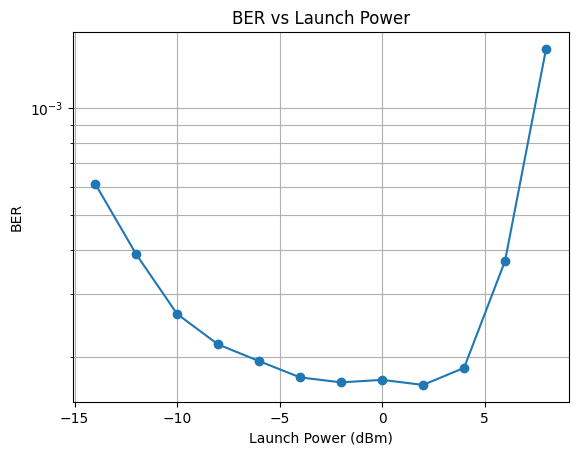

In [ ]:
P_launch_dbm_list = [-14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8]
ber_list = []

symbTx = symbolSource(paramSymb)

for P_launch in tqdm(P_launch_dbm_list, desc="Launch Power Sweep", unit="power"):

    y_CPR_1, d = simulate_optical_system(
        symbTx, paramSymb, paramPulse, paramIQM, sigLO,
        paramCh, paramLO, paramFE, paramPD,
        paramRxPulse, paramDec, paramEDC, paramEq, paramCPR,
        P_launch
    )

    ber  = perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec)
    ber_list.append(ber)

plt.figure()
plt.semilogy(P_launch_dbm_list, ber_list, 'o-')
plt.xlabel("Launch Power (dBm)")
plt.ylabel("BER")
plt.grid(True, which="both")
plt.title("BER vs Launch Power")
plt.show()



## BER vs Launch Power Graph

The **BER vs Launch Power** graph shows three distinct operating regions of the optical communication system.

---

### 1. Low Launch Power Region  
**Range:** approximately **-14 dBm to -4 dBm**

In this region, the **BER decreases clearly as launch power increases**.

This indicates that:

- The transmitted signal is **too weak at very low power levels**
- **ASE noise dominates**, limiting the effective signal quality
- Increasing launch power **improves the signal-to-noise ratio (SNR)**

As a result, the receiver can detect symbols more reliably and the **BER decreases**.

---

### 2. Optimum Operating Region  
**Range:** approximately **-2 dBm to +2 dBm**

In this region, the **BER reaches its minimum value**.

This indicates that:

- The transmitted power is **high enough to overcome noise**
- The power is **not yet high enough for nonlinear fiber effects to dominate**

From the graph, the optimum operating point appears to lie around **2 dBm**, with **-2 dBm, 0 dBm, and 2 dBm** showing very similar BER values.

This range therefore represents the **optimal launch power region** for the system.

---

### 3. High Launch Power Region  
**Range:** above approximately **+4 dBm**

In this region, the **BER begins to increase again**, especially beyond **6 dBm**.

This indicates that:

- **Nonlinear distortion becomes dominant**
- Effects such as **Self-Phase Modulation (SPM)** and other **nonlinear Kerr effects** distort the signal
- The system moves away from the optimal operating point

These nonlinear distortions degrade the constellation and increase the probability of symbol detection errors.

---

## U-Shaped BER Behaviour

Overall, the graph exhibits the expected **U-shaped BER vs Launch Power curve**:

- At **low launch powers**, the system is **noise-limited**, and BER decreases as launch power increases due to improved **SNR**.
- A **minimum BER** is observed in the **-2 dBm to +2 dBm region**, representing the **optimal operating point**.
- At **higher launch powers**, BER increases again as **nonlinear fiber impairments** become dominant.

---

## Validation of the Result

This graph provides a strong validation of the system behaviour because it demonstrates the **three expected operating regimes**:

1. **Low-power noise-limited region**
2. **Mid-power optimal operating region**
3. **High-power nonlinear-limited region**

This behaviour matches the expected physics of a **coherent optical transmission system**.

The graph also confirms that the simulation correctly captures the trade-off between:

- **ASE noise**, which dominates at **low launch powers**
- **Nonlinear Kerr effects**, which dominate at **high launch powers**

The optimal region around **-2 dBm to +2 dBm** is realistic for a **16-QAM coherent optical link** under these system conditions.